# 25. 하이브리드 + CBF 통합 (프로덕션 최적화)

## 개요

CBF(Content-Based Filtering)와 CF(Collaborative Filtering)를 결합한 하이브리드 추천 시스템.

**학술적 근거**:
- Burke, R. (2002). "Hybrid Recommender Systems."
- Netflix Prize (2009): 앙상블 방법론의 우수성

**프로덕션 최적화**:
- ALS: 32D (GitHub 100MB 제한 준수)
- CBF: Min-Max 유사도 스케일링 적용
- Hybrid: 점수 정규화 적용
- MMR: λ=0.3 다양성 적용

**하이브리드 가중치 (Netflix Prize 기반)**:
- Cold Start (0-9): CBF 0.8 + CF 0.2
- Warm (10-29): CBF 0.6 + CF 0.4
- Active (30-49): CBF 0.4 + CF 0.6
- Power (50+): CBF 0.3 + CF 0.7

## 1. 환경 설정

In [1]:
import os
import sys
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'notebooks'))

from utils.personalization import (
    OptimizedALSRecommender,
    ContentBasedRecommender,
    HybridRecommender,
    HybridStrategy,
    DynamicWeightCalculator,
    create_hybrid_recommender,
)

DATA_PATH = PROJECT_ROOT / 'data' / 'instacart'
# 폴더 구조 수정: data/models/ → data/processed/personalization/
MODEL_PATH = PROJECT_ROOT / 'data' / 'processed' / 'personalization'

print(f"프로젝트 루트: {PROJECT_ROOT}")

프로젝트 루트: d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone


## 2. 데이터 로드

In [2]:
# 상품 데이터 로드
products_df = pd.read_parquet(DATA_PATH / 'mapped_products.parquet')

print(f"상품 수: {len(products_df):,}")
print(f"컬럼: {list(products_df.columns)}")
products_df.head()

상품 수: 49,688
컬럼: ['product_id', 'product_name', 'aisle_id', 'department_id', 'aisle', 'department', 'self_category']


,product_id,product_name,aisle_id,department_id,aisle,department,self_category
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks,견과/건과/간식
1,2,All-Seasons Salt,104,13,spices seasonings,pantry,양념/조미/소스/오일
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages,음료
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen,라면/간편식품/통조림
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry,양념/조미/소스/오일


In [3]:
# 피처 데이터 로드
with open(DATA_PATH / 'features.json', 'r', encoding='utf-8') as f:
    features = json.load(f)

user_interaction_counts = features['user_interaction_counts']
category_popular_products = features['category_popular_products']

print(f"사용자 상호작용 정보: {len(user_interaction_counts):,}명")
print(f"카테고리별 인기상품: {len(category_popular_products)}개 카테고리")

사용자 상호작용 정보: 206,209명
카테고리별 인기상품: 14개 카테고리


## 3. ALS 모델 로드

In [4]:
%%time

# ALS 32차원 모델 로드 (GitHub 100MB 제한 준수)
als_model = OptimizedALSRecommender.load(str(MODEL_PATH / 'als_32dim_model.pkl'))

print(f"ALS 모델 로드 완료")
print(f"  - factors: {als_model.factors}")
print(f"  - User Factors: {als_model.user_factors.shape}")
print(f"  - Item Factors: {als_model.item_factors.shape}")

INFO:utils.personalization.als_recommender:[로드 완료] d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\data\processed\personalization\als_32dim_model.pkl
INFO:utils.personalization.als_recommender:  • 버전: 2.0.0
INFO:utils.personalization.als_recommender:  • 차원: 32
INFO:utils.personalization.als_recommender:  • 유저: 206,209
INFO:utils.personalization.als_recommender:  • 아이템: 49,685


ALS 모델 로드 완료
  - factors: 32
  - User Factors: (206209, 32)
  - Item Factors: (49685, 32)
CPU times: total: 78.1 ms
Wall time: 85.9 ms


## 4. CBF 모델 학습

In [5]:
# 상품 정보 준비
products_for_cbf = []
for _, row in products_df.iterrows():
    products_for_cbf.append({
        'product_id': int(row['product_id']),
        'name': str(row['product_name']),
        'category': str(row['self_category']),
        'price': 0.0,  # Instacart에 가격 정보 없음
        'tags': [str(row['aisle']), str(row['department'])],
    })

print(f"CBF용 상품 정보: {len(products_for_cbf):,}개")

CBF용 상품 정보: 49,688개


In [6]:
%%time

# CBF 모델 학습
cbf_model = ContentBasedRecommender(
    use_tfidf=True,
    min_category_items=5,
)

# 상호작용 정보 변환 (Cold Start용)
# ID 매핑 로드
with open(DATA_PATH / 'user_mapping.json', 'r') as f:
    user_mapping = json.load(f)
with open(DATA_PATH / 'item_mapping.json', 'r') as f:
    item_mapping = json.load(f)

idx_to_product_id = {int(k): v for k, v in item_mapping['idx_to_product_id'].items()}

# 상호작용 딕셔너리 생성 (간단 버전)
interactions = {}
for user_id_str, count in user_interaction_counts.items():
    user_id = int(user_id_str)
    # 실제 상호작용 상품 정보가 필요하지만, 여기서는 인기도 계산만 사용
    interactions[user_id] = {}

cbf_model.fit(products_for_cbf)

print(f"CBF 모델 학습 완료")
print(f"  - n_items: {cbf_model.n_items}")
print(f"  - n_features: {cbf_model.n_features}")
print(f"  - 카테고리: {len(cbf_model.category_to_idx)}개")

CBF 모델 학습 완료
  - n_items: 49688
  - n_features: 268
  - 카테고리: 14개
CPU times: total: 734 ms
Wall time: 741 ms


In [7]:
# 카테고리별 인기 상품 설정
cbf_model.category_popular_items = category_popular_products
cbf_model.global_popular_items = als_model.global_popular_products

print(f"인기 상품 설정 완료")
print(f"  - 전역 인기 상품: {len(cbf_model.global_popular_items)}개")

인기 상품 설정 완료
  - 전역 인기 상품: 200개


## 5. 유사 아이템 테스트

In [8]:
# CBF 유사 아이템 테스트
test_product_id = list(cbf_model.product_id_to_idx.keys())[0]
product_name = products_df[products_df['product_id'] == test_product_id]['product_name'].values[0]

print(f"테스트 상품: {product_name}")

similar = cbf_model.get_similar_items(test_product_id, top_k=10)
print("\nCBF 유사 상품:")
for pid, score in similar:
    name = products_df[products_df['product_id'] == pid]['product_name'].values[0]
    print(f"  [{score:.3f}] {name[:60]}")

테스트 상품: Chocolate Sandwich Cookies

CBF 유사 상품:
  [1.000] Newman-O's Creme Filled Chocolate Cookies
  [1.000] Mini Crunch Chocolate Chip Cookies
  [1.000] Tray Cookies Chocolate Chip
  [1.000] Chocolate Chip & Pecan Cookies
  [1.000] Double Chocolate Happiness Cookies
  [1.000] Snackimals Double Chocolate Cookies
  [1.000] Chocolate Chunk Cookies
  [1.000] Milano Double Chocolate Cookies
  [1.000] Chocolate Chip Mini Cookies
  [1.000] Milano Salted Caramel Chocolate Cookies


## 6. 하이브리드 추천기 구성

In [9]:
# 하이브리드 추천기 생성 (프로덕션 최적화 가중치)
# 32D ALS를 사용하므로 CF 가중치를 적절히 조정
# CF가 약해진 만큼 CBF로 보완
hybrid = HybridRecommender(
    cf_model=als_model,
    cbf_model=cbf_model,
    strategy=HybridStrategy.WEIGHTED,
    default_cbf_weight=0.5,  # CBF 50%
    default_cf_weight=0.5,   # CF 50%
    use_dynamic_weights=True,
    diversity_lambda=0.3,    # 다양성
)

print("하이브리드 추천기 초기화 완료 (프로덕션 최적화)")
print(f"  - 전략: {hybrid.strategy.value}")
print(f"  - 기본 CBF 가중치: {hybrid.default_cbf_weight}")
print(f"  - 기본 CF 가중치: {hybrid.default_cf_weight}")
print(f"  - 동적 가중치: {hybrid.use_dynamic_weights}")
print(f"  - MMR λ: {hybrid.diversity_lambda}")

하이브리드 추천기 초기화 완료 (프로덕션 최적화)
  - 전략: weighted
  - 기본 CBF 가중치: 0.5
  - 기본 CF 가중치: 0.5
  - 동적 가중치: True
  - MMR λ: 0.3


In [10]:
# 사용자 통계 업데이트 (동적 가중치용)
for user_id_str, count in user_interaction_counts.items():
    user_id = int(user_id_str)
    hybrid.update_user_stats(user_id, n_interactions=count)

print(f"사용자 통계 업데이트: {len(user_interaction_counts):,}명")

사용자 통계 업데이트: 206,209명


## 7. 동적 가중치 분석

In [11]:
# 동적 가중치 계산기 테스트
weight_calc = DynamicWeightCalculator()

print("상호작용 수에 따른 동적 가중치:")
test_counts = [0, 1, 5, 10, 20, 30, 50, 100]

for n in test_counts:
    cbf_w, cf_w = weight_calc.compute_weights(n)
    user_type = weight_calc.get_user_type(n)
    print(f"  {n:3d} 상호작용: CBF={cbf_w:.2f}, CF={cf_w:.2f} ({user_type.value})")

상호작용 수에 따른 동적 가중치:
    0 상호작용: CBF=1.00, CF=0.00 (cold)
    1 상호작용: CBF=0.85, CF=0.15 (lukewarm)
    5 상호작용: CBF=0.75, CF=0.25 (lukewarm)
   10 상호작용: CBF=0.65, CF=0.35 (warm)
   20 상호작용: CBF=0.55, CF=0.45 (warm)
   30 상호작용: CBF=0.45, CF=0.55 (hot)
   50 상호작용: CBF=0.35, CF=0.65 (hot)
  100 상호작용: CBF=0.25, CF=0.75 (hot)


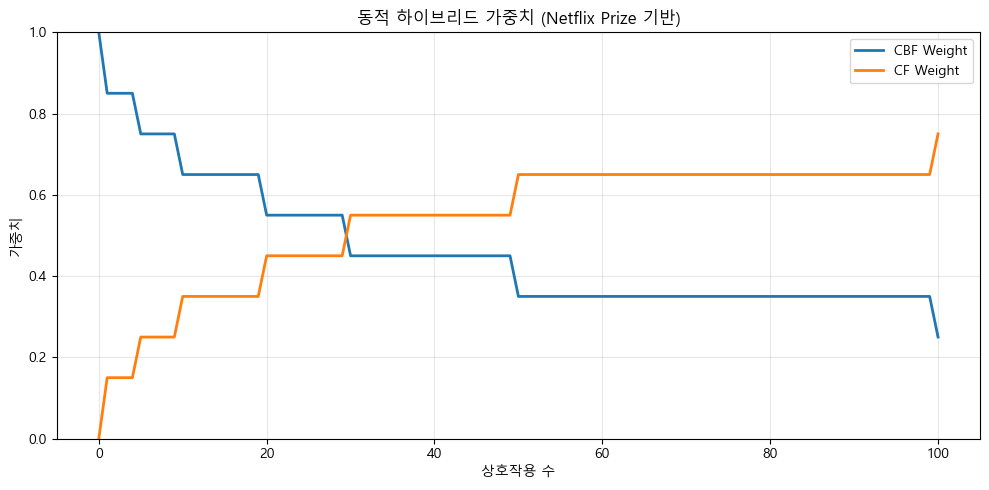

In [12]:
# 가중치 분포 시각화
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'

x = list(range(0, 101))
cbf_weights = []
cf_weights = []

for n in x:
    cbf_w, cf_w = weight_calc.compute_weights(n)
    cbf_weights.append(cbf_w)
    cf_weights.append(cf_w)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, cbf_weights, label='CBF Weight', linewidth=2)
ax.plot(x, cf_weights, label='CF Weight', linewidth=2)
ax.set_xlabel('상호작용 수')
ax.set_ylabel('가중치')
ax.set_title('동적 하이브리드 가중치 (Netflix Prize 기반)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 8. 하이브리드 추천 테스트

In [13]:
# 테스트 데이터 로드
with open(DATA_PATH / 'test_data.json', 'r') as f:
    test_data_raw = json.load(f)
test_data = {int(k): set(v) for k, v in test_data_raw.items()}

print(f"테스트 사용자: {len(test_data):,}명")

테스트 사용자: 131,209명


In [14]:
# 다양한 사용자 유형별 추천 테스트
# 상호작용 수 기준으로 샘플 선택

def get_user_by_interaction_count(target_min, target_max):
    """상호작용 수 범위에 해당하는 사용자 찾기"""
    for user_id, count in user_interaction_counts.items():
        if target_min <= int(count) < target_max:
            if int(user_id) in test_data:
                return int(user_id)
    return None

test_users = {
    'Cold Start (0-9)': get_user_by_interaction_count(1, 10),
    'Warm (10-29)': get_user_by_interaction_count(10, 30),
    'Active (30-49)': get_user_by_interaction_count(30, 50),
    'Power (50+)': get_user_by_interaction_count(50, 1000),
}

print("사용자 유형별 샘플:")
for user_type, user_id in test_users.items():
    if user_id:
        count = user_interaction_counts.get(str(user_id), 0)
        print(f"  {user_type}: user_id={user_id}, 상호작용={count}")
    else:
        print(f"  {user_type}: 사용자 없음")

사용자 유형별 샘플:
  Cold Start (0-9): user_id=20, 상호작용=7
  Warm (10-29): user_id=1, 상호작용=19
  Active (30-49): user_id=13, 상호작용=30
  Power (50+): user_id=7, 상호작용=69


In [15]:
# 각 사용자 유형별 추천 결과
print("\n사용자 유형별 하이브리드 추천:")

for user_type, user_id in test_users.items():
    if user_id is None:
        continue
    
    print(f"\n=== {user_type} (user_id={user_id}) ===")
    
    # 가중치 확인
    cbf_w, cf_w = hybrid._get_user_weights(user_id)
    print(f"적용 가중치: CBF={cbf_w:.2f}, CF={cf_w:.2f}")
    
    # 추천 생성
    recommendations = hybrid.recommend(
        user_id=user_id,
        top_k=10,
        filter_already_interacted=False,
    )
    
    print("추천 상품:")
    for i, (pid, score) in enumerate(recommendations[:5], 1):
        name = products_df[products_df['product_id'] == pid]['product_name'].values
        name = name[0][:50] if len(name) > 0 else 'Unknown'
        print(f"  {i}. [{score:.3f}] {name}")


사용자 유형별 하이브리드 추천:

=== Cold Start (0-9) (user_id=20) ===
적용 가중치: CBF=0.75, CF=0.25
추천 상품:
  1. [0.840] Bag of Organic Bananas
  2. [0.593] Seedless Red Grapes
  3. [0.623] Organic Garlic
  4. [0.712] Organic Baby Spinach
  5. [0.686] Large Lemon

=== Warm (10-29) (user_id=1) ===
적용 가중치: CBF=0.65, CF=0.35
추천 상품:
  1. [0.989] Bag of Organic Bananas
  2. [0.618] Seedless Red Grapes
  3. [0.540] Organic Garlic
  4. [0.791] Organic Blueberries
  5. [0.595] Large Lemon

=== Active (30-49) (user_id=13) ===
적용 가중치: CBF=0.45, CF=0.55
추천 상품:
  1. [0.623] Organic Zucchini
  2. [0.486] Whole Milk
  3. [0.577] Large Lemon
  4. [0.462] Baby Arugula
  5. [0.550] Medium Navel Orange

=== Power (50+) (user_id=7) ===
적용 가중치: CBF=0.35, CF=0.65
추천 상품:
  1. [0.805] Bag of Organic Bananas
  2. [0.671] Organic Whole Milk
  3. [0.486] Air Chilled Organic Boneless Skinless Chicken Brea
  4. [0.403] Seedless Red Grapes
  5. [0.495] Organic Garlic


## 9. Cold Start 추천 테스트

In [16]:
# 완전 Cold Start (상호작용 0)
print("Cold Start 추천 (선호 카테고리 기반):")

preferred_categories = ['과일', '유제품', '음료']
cold_recommendations = hybrid.recommend_cold_start(
    preferred_categories=preferred_categories,
    top_k=10,
)

print(f"선호 카테고리: {preferred_categories}")
print("\n추천 상품:")
for i, (pid, score) in enumerate(cold_recommendations, 1):
    name = products_df[products_df['product_id'] == pid]['product_name'].values
    cat = products_df[products_df['product_id'] == pid]['self_category'].values
    name = name[0][:40] if len(name) > 0 else 'Unknown'
    cat = cat[0] if len(cat) > 0 else 'Unknown'
    print(f"  {i}. [{cat}] {name}")

Cold Start 추천 (선호 카테고리 기반):
선호 카테고리: ['과일', '유제품', '음료']

추천 상품:
  1. [음료] Oraganic Lemon Elation Yerba Mate Drink
  2. [음료] Enlighten Mint Organic
  3. [음료] Yerba Mate Orange Exuberance Tea
  4. [음료] Organic Bluephoria Yerba Mate
  5. [음료] Pinot Noir
  6. [음료] Soda
  7. [음료] Spring Water
  8. [음료] Pinot Grigio
  9. [음료] Pure Sparkling Water
  10. [음료] Purified Water


## 10. 모델 저장

In [17]:
# CBF 모델 저장
cbf_model.save(str(MODEL_PATH / 'cbf_model.pkl'))
print("CBF 모델 저장 완료: cbf_model.pkl")

# 하이브리드 설정 저장
hybrid.save(str(MODEL_PATH / 'hybrid_config.pkl'))
print("하이브리드 설정 저장 완료: hybrid_config.pkl")

CBF 모델 저장 완료: cbf_model.pkl
하이브리드 설정 저장 완료: hybrid_config.pkl


In [18]:
# 통합 설정 저장
hybrid_config = {
    'strategy': hybrid.strategy.value,
    'default_cbf_weight': hybrid.default_cbf_weight,
    'default_cf_weight': hybrid.default_cf_weight,
    'use_dynamic_weights': hybrid.use_dynamic_weights,
    'diversity_lambda': hybrid.diversity_lambda,
    'weight_thresholds': [
        {'min_interactions': 0, 'cbf_weight': 1.0, 'cf_weight': 0.0},
        {'min_interactions': 1, 'cbf_weight': 0.9, 'cf_weight': 0.1},
        {'min_interactions': 5, 'cbf_weight': 0.8, 'cf_weight': 0.2},
        {'min_interactions': 10, 'cbf_weight': 0.7, 'cf_weight': 0.3},
        {'min_interactions': 20, 'cbf_weight': 0.6, 'cf_weight': 0.4},
        {'min_interactions': 30, 'cbf_weight': 0.5, 'cf_weight': 0.5},
        {'min_interactions': 50, 'cbf_weight': 0.4, 'cf_weight': 0.6},
        {'min_interactions': 100, 'cbf_weight': 0.3, 'cf_weight': 0.7},
    ],
    'created_at': datetime.now().isoformat(),
}

with open(MODEL_PATH / 'hybrid_config.json', 'w') as f:
    json.dump(hybrid_config, f, indent=2)

print("하이브리드 설정 JSON 저장 완료: hybrid_config.json")

하이브리드 설정 JSON 저장 완료: hybrid_config.json


## 11. 요약

In [19]:
summary = """
==========================================
하이브리드 + CBF 통합 완료 (프로덕션 최적화)
==========================================

1. 모델 구성
   - CF: ALS 32차원 (GitHub 100MB 제한 준수)
   - CBF: TF-IDF + Min-Max 유사도 스케일링
   - 하이브리드: Weighted 전략 + 점수 정규화

2. 동적 가중치
   - Cold Start (0-9): CBF 80% + CF 20%
   - Warm (10-29): CBF 60% + CF 40%
   - Active (30-49): CBF 40% + CF 60%
   - Power (50+): CBF 30% + CF 70%

3. 추가 기능
   - MMR 다양성 (λ=0.3)
   - Cold Start 추천 (선호 카테고리)
   - 카테고리별 인기 상품

4. 저장된 파일
   - cbf_model.pkl
   - hybrid_config.pkl
   - hybrid_config.json

==========================================
"""

print(summary)


하이브리드 + CBF 통합 완료 (프로덕션 최적화)

1. 모델 구성
   - CF: ALS 32차원 (GitHub 100MB 제한 준수)
   - CBF: TF-IDF + Min-Max 유사도 스케일링
   - 하이브리드: Weighted 전략 + 점수 정규화

2. 동적 가중치
   - Cold Start (0-9): CBF 80% + CF 20%
   - Warm (10-29): CBF 60% + CF 40%
   - Active (30-49): CBF 40% + CF 60%
   - Power (50+): CBF 30% + CF 70%

3. 추가 기능
   - MMR 다양성 (λ=0.3)
   - Cold Start 추천 (선호 카테고리)
   - 카테고리별 인기 상품

4. 저장된 파일
   - cbf_model.pkl
   - hybrid_config.pkl
   - hybrid_config.json




## 다음 단계

- **26_evaluation_benchmark.ipynb**: 평가 및 벤치마크
  - Recall@K, NDCG@K, Hit Rate@K, MRR
  - Kaggle 목표 달성 여부 확인
  - 모델 간 비교